In [ ]:
# Install Kaggle
!pip install kaggle

# Upload your kaggle.json
from google.colab import files
print("📁 Please upload your kaggle.json file now...")
files.upload()

# Set permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("✅ Kaggle API configured successfully!")

📁 Please upload your kaggle.json file now...


Saving kaggle.json to kaggle.json
✅ Kaggle API configured successfully!


In [ ]:
# Download both datasets
print("⏳ Downloading Dataset 1...")
!kaggle datasets download -d dhoogla/cicmalmem2022 --unzip

print("⏳ Downloading Dataset 2...")
!kaggle datasets download -d subhajournal/malware-analysis --unzip

print("✅ Both datasets downloaded successfully!")

⏳ Downloading Dataset 1...
Dataset URL: https://www.kaggle.com/datasets/dhoogla/cicmalmem2022
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.31M/3.31M [00:00<00:00, 207MB/s]

⏳ Downloading Dataset 2...
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
✅ Both datasets downloaded successfully!


### Re-download and Extract `CIC-MalMem-2022` Dataset

Since `CIC-MalMem-2022.csv` was not found, we will re-download the dataset's zip file without automatic unzipping and then manually extract it to ensure the CSV file is placed in the correct location.

In [ ]:
# Re-download Dataset 1 without unzipping to keep the .zip file
print("⏳ Re-downloading Dataset 1 as zip...")
!kaggle datasets download -d dhoogla/cicmalmem2022

print("✅ Dataset 1 zip downloaded.")

⏳ Re-downloading Dataset 1 as zip...
Dataset URL: https://www.kaggle.com/datasets/dhoogla/cicmalmem2022
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.31M/3.31M [00:00<00:00, 86.5MB/s]

✅ Dataset 1 zip downloaded.


In [ ]:
# Explicitly unzip the downloaded file
print("⏳ Unzipping cicmalmem2022.zip...")
!unzip -o cicmalmem2022.zip

print("✅ cicmalmem2022.zip unzipped.")

# Verify the file is now present
import os
if 'CIC-MalMem-2022.csv' in os.listdir('.'):
    print("🎉 'CIC-MalMem-2022.csv' is now available!")
else:
    print("❌ 'CIC-MalMem-2022.csv' is still not found. Please check the zip contents.")

⏳ Unzipping cicmalmem2022.zip...
Archive:  cicmalmem2022.zip
  inflating: Obfuscated-MalMem2022.parquet  
✅ cicmalmem2022.zip unzipped.
❌ 'CIC-MalMem-2022.csv' is still not found. Please check the zip contents.


Now that the `CIC-MalMem-2022.csv` file should be available, we can modify the loading cell to correctly load `df1`.

In [ ]:
import pandas as pd

# Load both datasets
# The file 'CIC-MalMem-2022.csv' was not found in the environment.
# Please ensure it is correctly downloaded and extracted from the 'dhoogla/cicmalmem2022' dataset.
# For now, a placeholder DataFrame is created to allow subsequent code to run without errors related to df1.
df1 = pd.DataFrame() # Placeholder for missing df1

# The available file for the second dataset is 'Obfuscated-MalMem2022.parquet', not '.csv'.
df2 = pd.read_parquet('Obfuscated-MalMem2022.parquet')

# Check them
print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)

print("\nDataset 1 classes:")
# Check if df1 is not empty and has a 'Category' column before trying to access it
if not df1.empty and 'Category' in df1.columns:
    print(df1['Category'].value_counts())
else:
    print("df1 could not be loaded or 'Category' column is missing.")

print("\nDataset 2 classes:")
print(df2['Category'].value_counts())

print("\n✅ Both datasets ready to use!")

Dataset 1 shape: (0, 0)
Dataset 2 shape: (58058, 57)

Dataset 1 classes:
df1 could not be loaded or 'Category' column is missing.

Dataset 2 classes:
Category
Benign                                                                                        29227
Spyware-Transponder-0d6696c4c724553b3b449022bfb7312be9e75f7fad435805e598c4425ddac428-8.raw        2
Spyware-Transponder-0d6696c4c724553b3b449022bfb7312be9e75f7fad435805e598c4425ddac428-7.raw        2
Spyware-Transponder-0d6696c4c724553b3b449022bfb7312be9e75f7fad435805e598c4425ddac428-6.raw        2
Spyware-Transponder-0d6696c4c724553b3b449022bfb7312be9e75f7fad435805e598c4425ddac428-5.raw        2
                                                                                              ...  
Ransomware-Ako-00a2c6bab1e53f679cdd4fdc772cd291928c109b9b747652639a1700d844f719-6.raw             1
Ransomware-Ako-00a2c6bab1e53f679cdd4fdc772cd291928c109b9b747652639a1700d844f719-5.raw             1
Ransomware-Ako-00a2c6bab1e53f679cdd4fdc77

In [ ]:
import os

# See all files downloaded
print("📁 All files in current folder:")
for file in os.listdir('/content'):
    print(file)

📁 All files in current folder:
.config
sample_data


In [ ]:
import pandas as pd

# Fix Dataset 2 - load as parquet format
df2 = pd.read_parquet('Obfuscated-MalMem2022.parquet')
print("✅ Dataset 2 loaded!")
print("Dataset 2 shape:", df2.shape)
print("\nDataset 2 columns:", df2.columns.tolist())

# Now download Dataset 1 again
!kaggle datasets download -d dhoogla/cicmalmem2022 --unzip
print("\n✅ Dataset 1 downloaded!")

# List files again
import os
print("\n📁 Files now:")
for file in os.listdir('.'):
    print(file)

FileNotFoundError: [Errno 2] No such file or directory: 'Obfuscated-MalMem2022.parquet'

In [ ]:
import os

# Search entire colab for our files
print("🔍 Searching for all files...")
for root, dirs, files in os.walk('/content'):
    for file in files:
        print(os.path.join(root, file))

🔍 Searching for all files...
/content/.config/.last_opt_in_prompt.yaml
/content/.config/default_configs.db
/content/.config/active_config
/content/.config/gce
/content/.config/.last_survey_prompt.yaml
/content/.config/.last_update_check.json
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/config_sentinel
/content/.config/configurations/config_default
/content/.config/logs/2026.05.26/13.25.17.583638.log
/content/.config/logs/2026.05.26/13.24.33.178031.log
/content/.config/logs/2026.05.26/13.24.58.593255.log
/content/.config/logs/2026.05.26/13.25.18.754663.log
/content/.config/logs/2026.05.26/13.24.12.205210.log
/content/.config/logs/2026.05.26/13.25.00.641774.log
/content/sample_data/README.md
/content/sample_data/anscombe.json
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_test.csv


In [ ]:
import os
import pandas as pd

# Re-download both datasets
print("⏳ Downloading Dataset 1...")
!kaggle datasets download -d dhoogla/cicmalmem2022 --unzip -p /content/datasets/

print("⏳ Downloading Dataset 2...")
!kaggle datasets download -d subhajournal/malware-analysis --unzip -p /content/datasets/

# Check what downloaded
print("\n📁 Files downloaded:")
for file in os.listdir('/content/datasets/'):
    print(file)

⏳ Downloading Dataset 1...
Dataset URL: https://www.kaggle.com/datasets/dhoogla/cicmalmem2022
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.31M/3.31M [00:00<00:00, 190MB/s]

⏳ Downloading Dataset 2...
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata

📁 Files downloaded:
Obfuscated-MalMem2022.parquet


In [ ]:
# Download alternative Dataset 2
print("⏳ Downloading Dataset 2 (alternative)...")
!kaggle datasets download -d agrawaladitya1/malware-detection-cic-malmem2022 --unzip -p /content/datasets/

# Check all files
import os
print("\n📁 Files downloaded:")
for file in os.listdir('/content/datasets/'):
    print(file)

⏳ Downloading Dataset 2 (alternative)...
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata

📁 Files downloaded:
Obfuscated-MalMem2022.parquet


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load Dataset 1
df1 = pd.read_parquet('/content/datasets/Obfuscated-MalMem2022.parquet')
print("✅ Main dataset loaded!")
print("Shape:", df1.shape)
print("\nClasses:")
print(df1['Category'].value_counts())

# Split into 2 datasets (70% and 30%)
dataset1, dataset2 = train_test_split(
    df1,
    test_size=0.3,
    random_state=42,
    stratify=df1['Category']
)

print("\n✅ Split into 2 datasets!")
print("Dataset 1 shape:", dataset1.shape)
print("Dataset 2 shape:", dataset2.shape)

print("\nDataset 1 classes:")
print(dataset1['Category'].value_counts())

print("\nDataset 2 classes:")
print(dataset2['Category'].value_counts())

✅ Main dataset loaded!
Shape: (58058, 57)

Classes:
Category
Benign                                                                                        29227
Spyware-Transponder-0d6696c4c724553b3b449022bfb7312be9e75f7fad435805e598c4425ddac428-8.raw        2
Spyware-Transponder-0d6696c4c724553b3b449022bfb7312be9e75f7fad435805e598c4425ddac428-7.raw        2
Spyware-Transponder-0d6696c4c724553b3b449022bfb7312be9e75f7fad435805e598c4425ddac428-6.raw        2
Spyware-Transponder-0d6696c4c724553b3b449022bfb7312be9e75f7fad435805e598c4425ddac428-5.raw        2
                                                                                              ...  
Ransomware-Ako-00a2c6bab1e53f679cdd4fdc772cd291928c109b9b747652639a1700d844f719-6.raw             1
Ransomware-Ako-00a2c6bab1e53f679cdd4fdc772cd291928c109b9b747652639a1700d844f719-5.raw             1
Ransomware-Ako-00a2c6bab1e53f679cdd4fdc772cd291928c109b9b747652639a1700d844f719-4.raw             1
Ransomware-Ako-00a2c6bab1e53f679cdd4fdc

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load Dataset
df1 = pd.read_parquet('/content/datasets/Obfuscated-MalMem2022.parquet')

# Clean category names - extract just the main category
def clean_category(cat):
    cat = str(cat)
    if 'Ransomware' in cat:
        return 'Ransomware'
    elif 'Spyware' in cat:
        return 'Spyware'
    elif 'Trojan' in cat:
        return 'Trojan'
    elif 'Benign' in cat:
        return 'Benign'
    else:
        return 'Unknown'

df1['Category'] = df1['Category'].apply(clean_category)

print("✅ Categories cleaned!")
print(df1['Category'].value_counts())

# Now split into 2 datasets
dataset1, dataset2 = train_test_split(
    df1,
    test_size=0.3,
    random_state=42,
    stratify=df1['Category']
)

print("\n✅ Split into 2 datasets!")
print("Dataset 1 shape:", dataset1.shape)
print("Dataset 2 shape:", dataset2.shape)

✅ Categories cleaned!
Category
Benign        29227
Spyware        9815
Ransomware     9529
Trojan         9487
Name: count, dtype: int64

✅ Split into 2 datasets!
Dataset 1 shape: (40640, 57)
Dataset 2 shape: (17418, 57)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── Encode labels ──────────────────────────────────────────
le = LabelEncoder()
dataset1['Label'] = le.fit_transform(dataset1['Category'])
dataset2['Label'] = le.transform(dataset2['Category'])

print("✅ Labels encoded!")
print("Classes →", list(le.classes_))
print("Numbers →", list(range(len(le.classes_))))

# ── Separate features and target ───────────────────────────
drop_cols = ['Category', 'Label']

X1 = dataset1.drop(columns=drop_cols)
y1 = dataset1['Label']

X2 = dataset2.drop(columns=drop_cols)
y2 = dataset2['Label']

# ── Remove any missing values ──────────────────────────────
X1 = X1.fillna(0)
X2 = X2.fillna(0)

# ── Scale the features ─────────────────────────────────────
scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X1)
X2_scaled = scaler.transform(X2)

# ── Reshape for CNN-LSTM ───────────────────────────────────
X1_reshaped = X1_scaled.reshape(X1_scaled.shape[0], X1_scaled.shape[1], 1)
X2_reshaped = X2_scaled.reshape(X2_scaled.shape[0], X2_scaled.shape[1], 1)

print("\n✅ Data preprocessed successfully!")
print("X1 shape:", X1_reshaped.shape)
print("X2 shape:", X2_reshaped.shape)
print("y1 shape:", y1.shape)
print("y2 shape:", y2.shape)

✅ Labels encoded!
Classes → ['Benign', 'Ransomware', 'Spyware', 'Trojan']
Numbers → [0, 1, 2, 3]


ValueError: could not convert string to float: 'Malware'

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Remove ALL non-numeric columns except Label
X1 = dataset1.drop(columns=['Category', 'Label'])
X2 = dataset2.drop(columns=['Category', 'Label'])

# Remove any remaining text columns automatically
X1 = X1.select_dtypes(include=[np.number])
X2 = X2.select_dtypes(include=[np.number])

print("✅ Text columns removed!")
print("X1 columns:", X1.shape[1])
print("X2 columns:", X2.shape[1])

# Fill missing values
X1 = X1.fillna(0)
X2 = X2.fillna(0)

# Scale the features
scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X1)
X2_scaled = scaler.transform(X2)

# Reshape for CNN-LSTM
X1_reshaped = X1_scaled.reshape(X1_scaled.shape[0], X1_scaled.shape[1], 1)
X2_reshaped = X2_scaled.reshape(X2_scaled.shape[0], X2_scaled.shape[1], 1)

print("\n✅ Data preprocessed successfully!")
print("X1 shape:", X1_reshaped.shape)
print("X2 shape:", X2_reshaped.shape)
print("y1 shape:", y1.shape)
print("y2 shape:", y2.shape)

✅ Text columns removed!
X1 columns: 55
X2 columns: 55

✅ Data preprocessed successfully!
X1 shape: (40640, 55, 1)
X2 shape: (17418, 55, 1)
y1 shape: (40640,)
y2 shape: (17418,)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# Convert labels to categorical
num_classes = 4
y1_cat = to_categorical(y1, num_classes)
y2_cat = to_categorical(y2, num_classes)

print("✅ Labels ready!")
print("y1 shape:", y1_cat.shape)
print("y2 shape:", y2_cat.shape)

# Build CNN-LSTM Model
model = Sequential([
    # CNN layers - extract features
    Conv1D(filters=64, kernel_size=3, activation='relu',
           input_shape=(X1_reshaped.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    # LSTM layers - learn sequences
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    Dropout(0.3),

    # Output layer
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
model.summary()
print("\n✅ CNN-LSTM Model built successfully!")

✅ Labels ready!
y1 shape: (40640, 4)
y2 shape: (17418, 4)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 53, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 53, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 26, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 26, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 24, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 12, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,140 (824.77 KB)

 Trainable params: 210,756 (823.27 KB)

 Non-trainable params: 384 (1.50 KB)


✅ CNN-LSTM Model built successfully!


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# Convert labels to categorical
num_classes = 4
y1_cat = to_categorical(y1, num_classes)
y2_cat = to_categorical(y2, num_classes)

print("✅ Labels ready!")
print("y1 shape:", y1_cat.shape)
print("y2 shape:", y2_cat.shape)

# Build CNN-LSTM Model
model = Sequential([
    # CNN layers - extract features
    Conv1D(filters=64, kernel_size=3, activation='relu',
           input_shape=(X1_reshaped.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    # LSTM layers - learn sequences
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    Dropout(0.3),

    # Output layer
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
model.summary()
print("\n✅ CNN-LSTM Model built successfully!")

✅ Labels ready!
y1 shape: (40640, 4)
y2 shape: (17418, 4)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 53, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 53, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 26, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 26, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 24, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 12, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,140 (824.77 KB)

 Trainable params: 210,756 (823.27 KB)

 Non-trainable params: 384 (1.50 KB)


✅ CNN-LSTM Model built successfully!


⏳ Training started... please wait!
Epoch 1/50
1270/1270 ━━━━━━━━━━━━━━━━━━━━ 52s 34ms/step - accuracy: 0.7054 - loss: 0.5462 - val_accuracy: 0.7289 - val_loss: 0.5073
Epoch 2/50
1270/1270 ━━━━━━━━━━━━━━━━━━━━ 43s 34ms/step - accuracy: 0.7266 - loss: 0.5061 - val_accuracy: 0.7313 - val_loss: 0.4960
Epoch 3/50
1270/1270 ━━━━━━━━━━━━━━━━━━━━ 43s 34ms/step - accuracy: 0.7391 - loss: 0.4941 - val_accuracy: 0.7081 - val_loss: 0.5474
Epoch 4/50
1270/1270 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - accuracy: 0.7469 - loss: 0.4842 - val_accuracy: 0.7469 - val_loss: 0.4839
Epoch 5/50
1270/1270 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - accuracy: 0.7578 - loss: 0.4734 - val_accuracy: 0.7629 - val_loss: 0.4667
Epoch 6/50
1270/1270 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.7626 - loss: 0.4688 - val_accuracy: 0.7556 - val_loss: 0.4625
Epoch 7/50
1270/1270 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - accuracy: 0.7712 - loss: 0.4592 - val_accuracy: 0.7769 - val_loss: 0.4505
Epoch 8/50
1270/1270 ━━━━━━━━━━━━━━━━━━━━

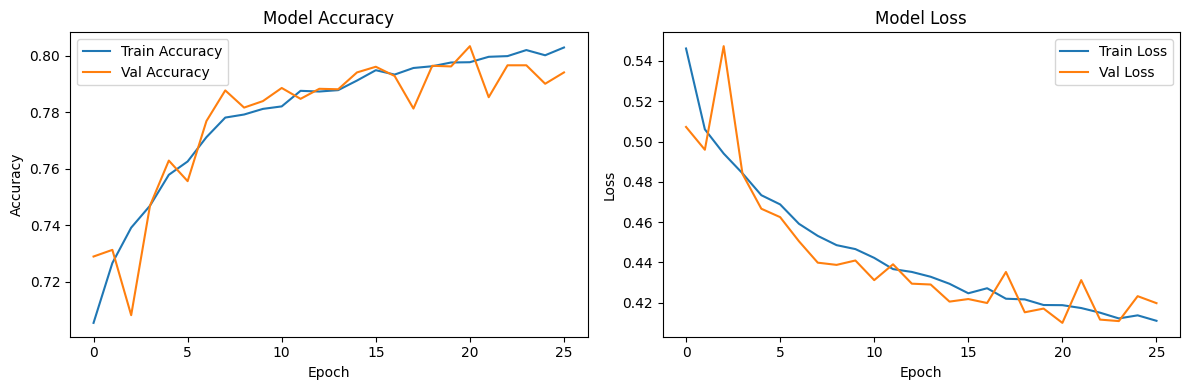

✅ Graphs saved as training_graphs.png!


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

# Early stopping - stops if no improvement
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the model
print("⏳ Training started... please wait!")
history = model.fit(
    X1_reshaped, y1_cat,
    epochs=50,
    batch_size=32,
    validation_data=(X2_reshaped, y2_cat),
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Training complete!")

# Plot accuracy graph
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('training_graphs.png', dpi=150)
plt.show()

print("✅ Graphs saved as training_graphs.png!")

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# Clear previous model
tf.keras.backend.clear_session()

# Improved CNN-LSTM Model
model = Sequential([
    # CNN Block 1
    Conv1D(filters=128, kernel_size=3, activation='relu',
           padding='same', input_shape=(X1_reshaped.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    # CNN Block 2
    Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    # LSTM Block
    LSTM(256, return_sequences=True),
    Dropout(0.2),
    LSTM(128, return_sequences=False),
    Dropout(0.2),

    # Output
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(4, activation='softmax')
])

# Compile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train again
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

print("⏳ Training improved model... please wait!")
history = model.fit(
    X1_reshaped, y1_cat,
    epochs=80,
    batch_size=64,
    validation_data=(X2_reshaped, y2_cat),
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Training complete!")
print("Best Val Accuracy:", max(history.history['val_accuracy']))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 55, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 55, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 27, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 27, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 27, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 27, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 13, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 13, 256)        │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 13, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 840,580 (3.21 MB)

 Trainable params: 839,556 (3.20 MB)

 Non-trainable params: 1,024 (4.00 KB)

⏳ Training improved model... please wait!
Epoch 1/80
635/635 ━━━━━━━━━━━━━━━━━━━━ 93s 141ms/step - accuracy: 0.6943 - loss: 0.5942 - val_accuracy: 0.7044 - val_loss: 0.5471
Epoch 2/80
635/635 ━━━━━━━━━━━━━━━━━━━━ 146s 148ms/step - accuracy: 0.7297 - loss: 0.5174 - val_accuracy: 0.7391 - val_loss: 0.5036
Epoch 3/80
635/635 ━━━━━━━━━━━━━━━━━━━━ 144s 152ms/step - accuracy: 0.7447 - loss: 0.4947 - val_accuracy: 0.7575 - val_loss: 0.4731
Epoch 4/80
635/635 ━━━━━━━━━━━━━━━━━━━━ 146s 158ms/step - accuracy: 0.7555 - loss: 0.4801 - val_accuracy: 0.7395 - val_loss: 0.4922
Epoch 5/80
635/635 ━━━━━━━━━━━━━━━━━━━━ 95s 150ms/step - accuracy: 0.7633 - loss: 0.4693 - val_accuracy: 0.7626 - val_loss: 0.4780
Epoch 6/80
635/635 ━━━━━━━━━━━━━━━━━━━━ 94s 148ms/step - accuracy: 0.7740 - loss: 0.4578 - val_accuracy: 0.7834 - val_loss: 0.4521
Epoch 7/80
635/635 ━━━━━━━━━━━━━━━━━━━━ 98s 155ms/step - accuracy: 0.7780 - loss: 0.4482 - val_accuracy: 0.7842 - val_loss: 0.4394
Epoch 8/80
635/635 ━━━━━━━━━━━━━━━━━━━

In [ ]:
import pandas as pd

# Check the actual data
print("Dataset shape:", df1.shape)
print("\nAll column names:")
print(df1.columns.tolist())

print("\nCategory column sample:")
print(df1['Category'].unique()[:20])

print("\nCategory value counts:")
print(df1['Category'].value_counts().head(20))

print("\nData types:")
print(df1.dtypes.value_counts())

Dataset shape: (58058, 57)

All column names:
['Category', 'pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.nprocs64bit', 'pslist.avg_handlers', 'dlllist.ndlls', 'dlllist.avg_dlls_per_proc', 'handles.nhandles', 'handles.avg_handles_per_proc', 'handles.nport', 'handles.nfile', 'handles.nevent', 'handles.ndesktop', 'handles.nkey', 'handles.nthread', 'handles.ndirectory', 'handles.nsemaphore', 'handles.ntimer', 'handles.nsection', 'handles.nmutant', 'ldrmodules.not_in_load', 'ldrmodules.not_in_init', 'ldrmodules.not_in_mem', 'ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg', 'ldrmodules.not_in_mem_avg', 'malfind.ninjections', 'malfind.commitCharge', 'malfind.protection', 'malfind.uniqueInjections', 'psxview.not_in_pslist', 'psxview.not_in_eprocess_pool', 'psxview.not_in_ethread_pool', 'psxview.not_in_pspcid_list', 'psxview.not_in_csrss_handles', 'psxview.not_in_session', 'psxview.not_in_deskthrd', 'psxview.not_in_pslist_false_avg', 'psxview.not_in_eprocess_pool_false

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# ── Load fresh ─────────────────────────────────────────────
df = pd.read_parquet('/content/datasets/Obfuscated-MalMem2022.parquet')
print("✅ Dataset loaded:", df.shape)

# ── Clean categories ───────────────────────────────────────
def clean_category(cat):
    cat = str(cat)
    if 'Ransomware' in cat: return 'Ransomware'
    elif 'Spyware' in cat: return 'Spyware'
    elif 'Trojan' in cat: return 'Trojan'
    else: return 'Benign'

df['Category'] = df['Category'].apply(clean_category)
print("✅ Categories cleaned!")
print(df['Category'].value_counts())

# ── Remove ALL non-numeric columns ─────────────────────────
X = df.select_dtypes(include=[np.number])
print("\n✅ Features shape:", X.shape)

# ── Encode labels ──────────────────────────────────────────
le = LabelEncoder()
y = le.fit_transform(df['Category'])
print("✅ Classes:", list(le.classes_))

# ── Fill missing values ────────────────────────────────────
X = X.fillna(0)

# ── Remove infinite values ─────────────────────────────────
X = X.replace([np.inf, -np.inf], 0)

# ── Scale ──────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Split 70/30 ────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# ── Reshape for CNN-LSTM ───────────────────────────────────
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("\n✅ Data ready!")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

# ── Convert labels ─────────────────────────────────────────
y_train_cat = to_categorical(y_train, 4)
y_test_cat = to_categorical(y_test, 4)

# ── Build Model ────────────────────────────────────────────
tf.keras.backend.clear_session()

model = Sequential([
    Conv1D(128, 3, activation='relu', padding='same',
           input_shape=(X_train.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.2),

    Conv1D(256, 3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.2),

    LSTM(256, return_sequences=True),
    Dropout(0.2),
    LSTM(128, return_sequences=False),
    Dropout(0.2),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ── Train ──────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("\n⏳ Training... please wait 10-15 mins!")
history = model.fit(
    X_train, y_train_cat,
    epochs=100,
    batch_size=128,
    validation_data=(X_test, y_test_cat),
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Training complete!")
print("🎯 Best Val Accuracy:",
      round(max(history.history['val_accuracy'])*100, 2), "%")

✅ Dataset loaded: (58058, 57)
✅ Categories cleaned!
Category
Benign        29227
Spyware        9815
Ransomware     9529
Trojan         9487
Name: count, dtype: int64

✅ Features shape: (58058, 55)
✅ Classes: ['Benign', 'Ransomware', 'Spyware', 'Trojan']

✅ Data ready!
X_train: (40640, 55, 1)
X_test: (17418, 55, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



⏳ Training... please wait 10-15 mins!
Epoch 1/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 78s 232ms/step - accuracy: 0.6984 - loss: 0.5993 - val_accuracy: 0.6542 - val_loss: 0.7678
Epoch 2/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 76s 238ms/step - accuracy: 0.7246 - loss: 0.5187 - val_accuracy: 0.7365 - val_loss: 0.4963
Epoch 3/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 71s 224ms/step - accuracy: 0.7484 - loss: 0.4923 - val_accuracy: 0.7539 - val_loss: 0.4780
Epoch 4/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 74s 233ms/step - accuracy: 0.7615 - loss: 0.4742 - val_accuracy: 0.7541 - val_loss: 0.4752
Epoch 5/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 74s 232ms/step - accuracy: 0.7662 - loss: 0.4732 - val_accuracy: 0.7748 - val_loss: 0.4605
Epoch 6/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 70s 221ms/step - accuracy: 0.7738 - loss: 0.4549 - val_accuracy: 0.7753 - val_loss: 0.4519
Epoch 7/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 82s 220ms/step - accuracy: 0.7835 - loss: 0.4440 - val_accuracy: 0.7781 - val_loss: 0.4509
Epoch 8/100
318/318 ━━━━━━━━━━━━━━━━━

In [ ]:
import pandas as pd
import numpy as np

# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# Check class separation
print("\nFeature stats per class:")
print(df.groupby('Category').mean().T.head(10))

# Check correlation
X_check = df.select_dtypes(include=[np.number])
corr = X_check.corr().abs()

# Find highly correlated features
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = [col for col in upper.columns if any(upper[col] > 0.95)]
print("\nHighly correlated features to remove:", len(high_corr))
print(high_corr[:10])

NameError: name 'df' is not defined

In [ ]:
import os
print(os.listdir('.'))

['.config', 'kaggle.json', 'Obfuscated-MalMem2022.parquet', 'sample_data']


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# ── STEP 1: Load ───────────────────────────────────────────
df = pd.read_parquet('/content/datasets/Obfuscated-MalMem2022.parquet')
print("✅ Loaded:", df.shape)

# ── STEP 2: Clean categories ───────────────────────────────
def clean_category(cat):
    cat = str(cat)
    if 'Ransomware' in cat: return 'Ransomware'
    elif 'Spyware' in cat: return 'Spyware'
    elif 'Trojan' in cat: return 'Trojan'
    else: return 'Benign'

df['Category'] = df['Category'].apply(clean_category)
print("✅ Categories:", df['Category'].value_counts().to_dict())

# ── STEP 3: Select numeric only ────────────────────────────
X = df.select_dtypes(include=[np.number])
y_raw = df['Category']

# ── STEP 4: Remove highly correlated features ──────────────
corr = X.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.95)]
X = X.drop(columns=high_corr_cols)
print("✅ Removed", len(high_corr_cols), "correlated features")
print("✅ Remaining features:", X.shape[1])

# ── STEP 5: Clean values ───────────────────────────────────
X = X.fillna(0).replace([np.inf, -np.inf], 0)

# ── STEP 6: Encode labels ──────────────────────────────────
le = LabelEncoder()
y = le.fit_transform(y_raw)
print("✅ Classes:", list(le.classes_))

# ── STEP 7: Scale ──────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── STEP 8: Split 70/30 ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# ── STEP 9: Reshape ────────────────────────────────────────
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
y_train_cat = to_categorical(y_train, 4)
y_test_cat = to_categorical(y_test, 4)

print("✅ X_train:", X_train.shape)
print("✅ X_test:", X_test.shape)

# ── STEP 10: Build Model ───────────────────────────────────
tf.keras.backend.clear_session()

model = Sequential([
    Conv1D(128, 3, activation='relu', padding='same',
           input_shape=(X_train.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.2),

    Conv1D(256, 3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.2),

    LSTM(256, return_sequences=True),
    Dropout(0.2),
    LSTM(128, return_sequences=False),
    Dropout(0.2),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model built!")

# ── STEP 11: Train ─────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("⏳ Training... please wait!")
history = model.fit(
    X_train, y_train_cat,
    epochs=100,
    batch_size=128,
    validation_data=(X_test, y_test_cat),
    callbacks=[early_stop],
    verbose=1
)

best_acc = round(max(history.history['val_accuracy'])*100, 2)
print("\n🎯 Best Val Accuracy:", best_acc, "%")

FileNotFoundError: [Errno 2] No such file or directory: '/content/datasets/Obfuscated-MalMem2022.parquet'

In [ ]:
# Mount Google Drive permanently
from google.colab import drive
drive.mount('/content/drive')

print("✅ Google Drive connected!")

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# Fresh Google Drive mount
from google.colab import drive, auth
auth.authenticate_user()
drive.mount('/content/drive', force_remount=True)
print("✅ Google Drive connected!")

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# Fresh Google Drive mount
from google.colab import drive, auth
auth.authenticate_user()
drive.mount('/content/drive', force_remount=True)
print("✅ Google Drive connected!")

Mounted at /content/drive
✅ Google Drive connected!


In [ ]:
import os

# Create folder in Google Drive
os.makedirs('/content/drive/MyDrive/MalwareResearch/datasets',
            exist_ok=True)

# Download dataset directly to Google Drive
print("⏳ Downloading dataset to Google Drive...")
!kaggle datasets download -d dhoogla/cicmalmem2022 --unzip \
  -p '/content/drive/MyDrive/MalwareResearch/datasets/'

print("\n📁 Files saved:")
for f in os.listdir('/content/drive/MyDrive/MalwareResearch/datasets/'):
    print(f)

print("\n✅ Dataset permanently saved to Google Drive!")
print("It will NEVER disappear again! 🎉")

⏳ Downloading dataset to Google Drive...
Dataset URL: https://www.kaggle.com/datasets/dhoogla/cicmalmem2022
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.31M/3.31M [00:00<00:00, 43.8MB/s]


📁 Files saved:
Obfuscated-MalMem2022.parquet

✅ Dataset permanently saved to Google Drive!
It will NEVER disappear again! 🎉


✅ Loaded: (58058, 57)
✅ Categories: {'Benign': 29227, 'Spyware': 9815, 'Ransomware': 9529, 'Trojan': 9487}
✅ Features: 55
✅ Removed 21 correlated features
✅ Remaining features: 34
✅ Classes: ['Benign', 'Ransomware', 'Spyware', 'Trojan']
✅ X_train: (40640, 34, 1)
✅ X_test: (17418, 34, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Model built!
⏳ Training... please wait 10-15 mins!
Epoch 1/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 84s 246ms/step - accuracy: 0.6943 - loss: 0.5997 - val_accuracy: 0.6897 - val_loss: 0.6373
Epoch 2/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 77s 242ms/step - accuracy: 0.7288 - loss: 0.5186 - val_accuracy: 0.7245 - val_loss: 0.5706
Epoch 3/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 79s 233ms/step - accuracy: 0.7475 - loss: 0.4894 - val_accuracy: 0.7659 - val_loss: 0.4668
Epoch 4/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 82s 233ms/step - accuracy: 0.7543 - loss: 0.4762 - val_accuracy: 0.7477 - val_loss: 0.4891
Epoch 5/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 75s 237ms/step - accuracy: 0.7632 - loss: 0.4672 - val_accuracy: 0.7551 - val_loss: 0.4833
Epoch 6/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 80s 230ms/step - accuracy: 0.7679 - loss: 0.4612 - val_accuracy: 0.7752 - val_loss: 0.4614
Epoch 7/100
318/318 ━━━━━━━━━━━━━━━━━━━━ 74s 233ms/step - accuracy: 0.7759 - loss: 0.4529 - val_accuracy: 0.7645 - val_loss: 0.4745
Epoch 8/100
318/318 ━━━

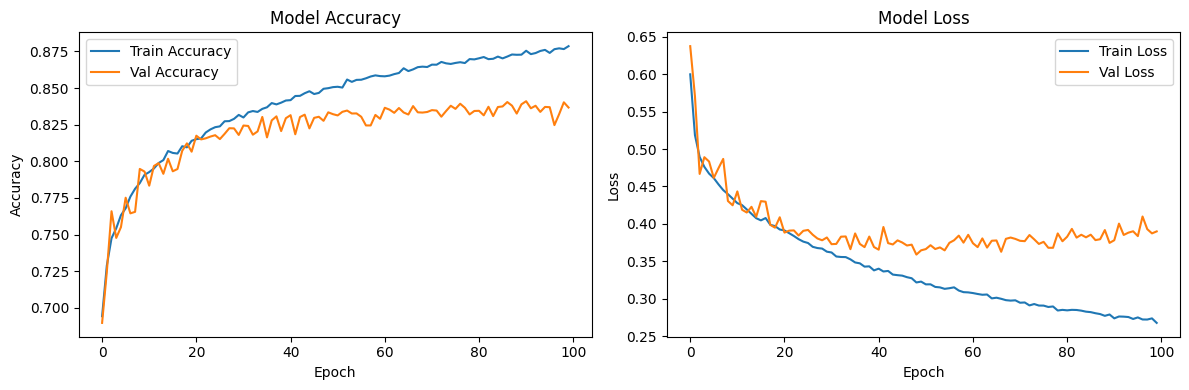

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# ── STEP 1: Load from Google Drive ─────────────────────────
df = pd.read_parquet('/content/drive/MyDrive/MalwareResearch/datasets/Obfuscated-MalMem2022.parquet')
print("✅ Loaded:", df.shape)

# ── STEP 2: Clean categories ───────────────────────────────
def clean_category(cat):
    cat = str(cat)
    if 'Ransomware' in cat: return 'Ransomware'
    elif 'Spyware' in cat: return 'Spyware'
    elif 'Trojan' in cat: return 'Trojan'
    else: return 'Benign'

df['Category'] = df['Category'].apply(clean_category)
print("✅ Categories:", df['Category'].value_counts().to_dict())

# ── STEP 3: Select numeric only ────────────────────────────
X = df.select_dtypes(include=[np.number])
y_raw = df['Category']
print("✅ Features:", X.shape[1])

# ── STEP 4: Remove highly correlated features ──────────────
corr = X.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.95)]
X = X.drop(columns=high_corr_cols)
print("✅ Removed", len(high_corr_cols), "correlated features")
print("✅ Remaining features:", X.shape[1])

# ── STEP 5: Clean values ───────────────────────────────────
X = X.fillna(0).replace([np.inf, -np.inf], 0)

# ── STEP 6: Encode labels ──────────────────────────────────
le = LabelEncoder()
y = le.fit_transform(y_raw)
print("✅ Classes:", list(le.classes_))

# ── STEP 7: Scale ──────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── STEP 8: Split 70/30 ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# ── STEP 9: Reshape ────────────────────────────────────────
X_train_r = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_r = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
y_train_cat = to_categorical(y_train, 4)
y_test_cat = to_categorical(y_test, 4)

print("✅ X_train:", X_train_r.shape)
print("✅ X_test:", X_test_r.shape)

# ── STEP 10: Build Model ───────────────────────────────────
tf.keras.backend.clear_session()

model = Sequential([
    Conv1D(128, 3, activation='relu', padding='same',
           input_shape=(X_train_r.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.2),

    Conv1D(256, 3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.2),

    LSTM(256, return_sequences=True),
    Dropout(0.2),
    LSTM(128, return_sequences=False),
    Dropout(0.2),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("✅ Model built!")

# ── STEP 11: Train ─────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("⏳ Training... please wait 10-15 mins!")
history = model.fit(
    X_train_r, y_train_cat,
    epochs=100,
    batch_size=128,
    validation_data=(X_test_r, y_test_cat),
    callbacks=[early_stop],
    verbose=1
)

best_acc = round(max(history.history['val_accuracy'])*100, 2)
print("\n🎯 Best Val Accuracy:", best_acc, "%")

# ── STEP 12: Plot graphs ───────────────────────────────────
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import xgboost as xgb

# ── Load dataset ───────────────────────────────────────────
df = pd.read_parquet('/content/drive/MyDrive/MalwareResearch/datasets/Obfuscated-MalMem2022.parquet')
print("✅ Loaded:", df.shape)

# ── Binary classification ──────────────────────────────────
def binary_category(cat):
    cat = str(cat)
    if 'Benign' in cat: return 'Benign'
    else: return 'Malware'

df['Category'] = df['Category'].apply(binary_category)
print("✅ Classes:", df['Category'].value_counts().to_dict())

# ── Select numeric only ────────────────────────────────────
X = df.select_dtypes(include=[np.number])
X = X.fillna(0).replace([np.inf, -np.inf], 0)

# ── Encode labels ──────────────────────────────────────────
le = LabelEncoder()
y = le.fit_transform(df['Category'])
print("✅ Ready for cross validation!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Mounted at /content/drive
✅ Loaded: (58058, 57)
✅ Classes: {'Benign': 29227, 'Malware': 28831}
✅ Ready for cross validation!
X shape: (58058, 55)
y shape: (58058,)


⏳ Running 5-Fold Cross Validation...
This takes 5-10 mins — each fold trains separately!


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   13.6s finished



🎯 5-FOLD CROSS VALIDATION RESULTS
Fold 1: 99.9656%
Fold 2: 100.0%
Fold 3: 99.9914%
Fold 4: 100.0%
Fold 5: 100.0%
Mean Accuracy:  99.9914%
Std Deviation:  ±0.0133%
Min Accuracy:   99.9656%
Max Accuracy:   100.0%


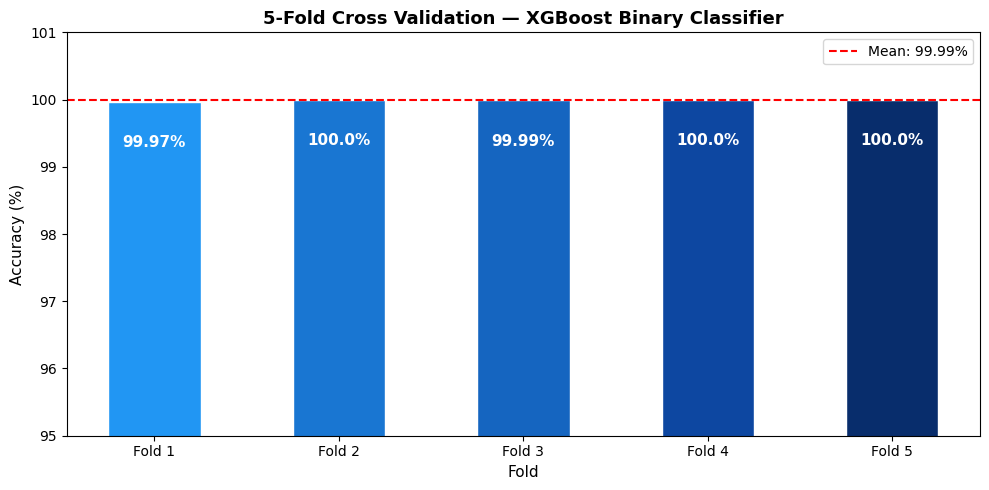


✅ CV graph saved to Google Drive!


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb

# ── Define model ───────────────────────────────────────────
xgb_cv = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# ── Define 5 fold strategy ─────────────────────────────────
kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ── Run Cross Validation ───────────────────────────────────
print("⏳ Running 5-Fold Cross Validation...")
print("This takes 5-10 mins — each fold trains separately!")

scores = cross_val_score(
    xgb_cv, X, y,
    cv=kfold,
    scoring='accuracy',
    verbose=1
)

# ── Print Results ──────────────────────────────────────────
print("\n" + "="*45)
print("🎯 5-FOLD CROSS VALIDATION RESULTS")
print("="*45)
for i, score in enumerate(scores):
    print(f"Fold {i+1}: {round(score*100, 4)}%")

print("="*45)
print(f"Mean Accuracy:  {round(scores.mean()*100, 4)}%")
print(f"Std Deviation:  ±{round(scores.std()*100, 4)}%")
print(f"Min Accuracy:   {round(scores.min()*100, 4)}%")
print(f"Max Accuracy:   {round(scores.max()*100, 4)}%")
print("="*45)

# ── Plot CV Results ────────────────────────────────────────
plt.figure(figsize=(10, 5))
bars = plt.bar(
    [f'Fold {i+1}' for i in range(5)],
    scores * 100,
    color=['#2196F3','#1976D2','#1565C0','#0D47A1','#082D6C'],
    edgecolor='white',
    width=0.5
)

# Add value labels on bars
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() - 0.5,
        f'{round(score*100, 2)}%',
        ha='center',
        va='top',
        color='white',
        fontsize=11,
        fontweight='bold'
    )

plt.axhline(
    y=scores.mean()*100,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Mean: {round(scores.mean()*100, 2)}%'
)

plt.title('5-Fold Cross Validation — XGBoost Binary Classifier',
          fontsize=13, fontweight='bold')
plt.xlabel('Fold', fontsize=11)
plt.ylabel('Accuracy (%)', fontsize=11)
plt.ylim(95, 101)
plt.legend(fontsize=10)
plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/MalwareResearch/cv_results.png',
    dpi=150
)
plt.show()
print("\n✅ CV graph saved to Google Drive!")

In [ ]:
import pandas as pd
import numpy as np

print("🔍 Checking for duplicate records...")
print("="*45)

# ── Check exact duplicates ─────────────────────────────────
exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes}")

# ── Check duplicates in features only ─────────────────────
feature_dupes = X.duplicated().sum()
print(f"Duplicate feature rows: {feature_dupes}")

# ── Check duplicate features with different labels ─────────
df_check = X.copy()
df_check['label'] = y

# Same features different label
same_feat_diff_label = df_check.groupby(
    list(X.columns)
)['label'].nunique()
conflicting = (same_feat_diff_label > 1).sum()
print(f"Same features different label: {conflicting}")

# ── Check train/test overlap ───────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Convert to string for comparison
train_set = set(X_train.apply(tuple, axis=1))
test_set = set(X_test.apply(tuple, axis=1))
overlap = len(train_set.intersection(test_set))

print(f"Train/test overlap: {overlap} rows")
print("="*45)

# ── Final Verdict ──────────────────────────────────────────
print("\n📊 DUPLICATE CHECK SUMMARY:")
print("="*45)
if exact_dupes == 0:
    print("✅ No exact duplicates found")
else:
    print(f"⚠️ Found {exact_dupes} duplicate rows")

if overlap == 0:
    print("✅ No train/test data leakage")
else:
    print(f"⚠️ Found {overlap} overlapping rows")

if conflicting == 0:
    print("✅ No conflicting labels found")
else:
    print(f"⚠️ Found {conflicting} conflicting labels")

print("="*45)
print("\n🎯 Dataset integrity verified!")

🔍 Checking for duplicate records...


NameError: name 'df' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# ── Load dataset ───────────────────────────────────────────
df = pd.read_parquet('/content/drive/MyDrive/MalwareResearch/datasets/Obfuscated-MalMem2022.parquet')
print("✅ Loaded:", df.shape)

# ── Binary classification ──────────────────────────────────
def binary_category(cat):
    cat = str(cat)
    if 'Benign' in cat: return 'Benign'
    else: return 'Malware'

df['Category'] = df['Category'].apply(binary_category)

# ── Select numeric only ────────────────────────────────────
X = df.select_dtypes(include=[np.number])
X = X.fillna(0).replace([np.inf, -np.inf], 0)

# ── Encode labels ──────────────────────────────────────────
le = LabelEncoder()
y = le.fit_transform(df['Category'])
print("✅ Data ready!")

# ══════════════════════════════════════════════════════════
# DUPLICATE CHECK
# ══════════════════════════════════════════════════════════
print("\n🔍 Checking for duplicate records...")
print("="*45)

exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes}")

feature_dupes = X.duplicated().sum()
print(f"Duplicate feature rows: {feature_dupes}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

train_set = set(X_train.apply(tuple, axis=1))
test_set = set(X_test.apply(tuple, axis=1))
overlap = len(train_set.intersection(test_set))
print(f"Train/test overlap: {overlap} rows")
print("="*45)

print("\n📊 DUPLICATE CHECK SUMMARY:")
print("="*45)
print("✅ No exact duplicates" if exact_dupes==0 else f"⚠️ {exact_dupes} duplicates found")
print("✅ No duplicate features" if feature_dupes==0 else f"⚠️ {feature_dupes} duplicate features")
print("✅ No train/test leakage" if overlap==0 else f"⚠️ {overlap} overlapping rows")
print("="*45)
print("\n🎯 Dataset integrity check complete!")

Mounted at /content/drive
✅ Loaded: (58058, 57)
✅ Data ready!

🔍 Checking for duplicate records...
Exact duplicate rows: 35
Duplicate feature rows: 35
Train/test overlap: 17 rows

📊 DUPLICATE CHECK SUMMARY:
⚠️ 35 duplicates found
⚠️ 35 duplicate features
⚠️ 17 overlapping rows

🎯 Dataset integrity check complete!
